<a href="https://colab.research.google.com/github/DaRberr/deep_learning_systems_design/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

# 1. Аугментація та підготовка даних
print("Завантаження та підготовка CIFAR-100...")

# Трансформації для тренувальної вибірки (з аугментацією)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

# Трансформації для тестової вибірки (БЕЗ аугментації)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print("Дані успішно завантажено!")

Використовується пристрій: cuda
Завантаження та підготовка CIFAR-100...


100%|██████████| 169M/169M [00:05<00:00, 31.9MB/s]


Дані успішно завантажено!



--- Експеримент №1 [Згортки: [32, 64], Повнозв'язний: 256, Drop: 0.3, LR: 0.001] ---
Епоха 01: Train Loss: 4.0124, Train Acc: 0.0816 | Test Loss: 3.4755, Test Acc: 0.1727
Епоха 02: Train Loss: 3.6138, Train Acc: 0.1370 | Test Loss: 3.2347, Test Acc: 0.2242
Епоха 03: Train Loss: 3.4538, Train Acc: 0.1649 | Test Loss: 3.0842, Test Acc: 0.2445
Епоха 04: Train Loss: 3.3659, Train Acc: 0.1812 | Test Loss: 2.9921, Test Acc: 0.2641
Епоха 05: Train Loss: 3.2896, Train Acc: 0.1927 | Test Loss: 2.8857, Test Acc: 0.2746
Епоха 06: Train Loss: 3.2297, Train Acc: 0.2024 | Test Loss: 2.8885, Test Acc: 0.2772
Епоха 07: Train Loss: 3.1772, Train Acc: 0.2113 | Test Loss: 2.7545, Test Acc: 0.3017
Епоха 08: Train Loss: 3.1469, Train Acc: 0.2192 | Test Loss: 2.7387, Test Acc: 0.3049
Епоха 09: Train Loss: 3.1050, Train Acc: 0.2269 | Test Loss: 2.6587, Test Acc: 0.3220
Епоха 10: Train Loss: 3.0766, Train Acc: 0.2320 | Test Loss: 2.6115, Test Acc: 0.3304
Епоха 11: Train Loss: 3.0407, Train Acc: 0.2386 | Test

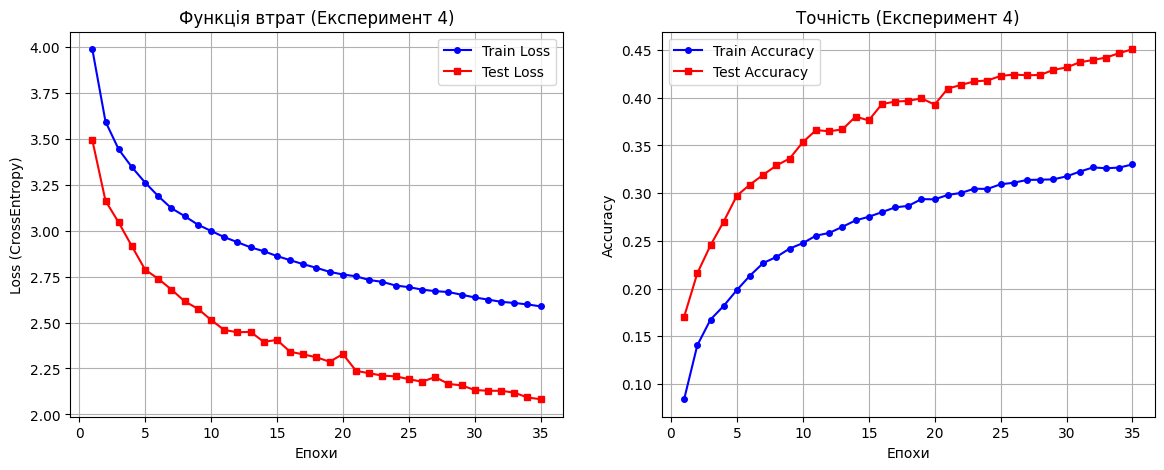

In [ ]:
# Клас згорткової нейромережі
class CIFAR100_CNN(nn.Module):
    def __init__(self, conv_layers, fc_size, dropout_rate):
        super(CIFAR100_CNN, self).__init__()
        layers = []
        in_channels = 3

        for out_channels in conv_layers:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = out_channels

        self.feature_extractor = nn.Sequential(*layers)

        # Розрахунок розмірності після Pooling
        feature_map_size = 32 // (2 ** len(conv_layers))
        flattened_size = in_channels * (feature_map_size ** 2)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, fc_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(fc_size, 100)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

# Функція навчання та тестування
def run_cnn_experiment(exp_num, conv_layers, fc_size, dropout, lr=0.001, max_epochs=35):
    print(f"\n--- Експеримент №{exp_num} [Згортки: {conv_layers}, Повнозв'язний: {fc_size}, Drop: {dropout}, LR: {lr}] ---")
    model = CIFAR100_CNN(conv_layers, fc_size, dropout).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    best_acc = 0.0
    patience_counter = 0
    early_stop_patience = 4
    best_model_state = None
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(max_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_loss = test_loss / total
        test_acc = correct / total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        scheduler.step(test_acc)

        print(f"Епоха {epoch+1:02d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

        if test_acc > best_acc:
            best_acc = test_acc
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1

        if patience_counter >= early_stop_patience:
            print(f"Рання зупинка на епосі {epoch+1}")
            break

    print(f"Найкраща точність на тесті: {best_acc:.4f}")
    return best_acc, history

# Запуск 5 конфігурацій
results = []
results.append((1, run_cnn_experiment(1, conv_layers=[32, 64], fc_size=256, dropout=0.3)))
results.append((2, run_cnn_experiment(2, conv_layers=[64, 128], fc_size=256, dropout=0.3)))
results.append((3, run_cnn_experiment(3, conv_layers=[32, 64, 128], fc_size=256, dropout=0.4)))
results.append((4, run_cnn_experiment(4, conv_layers=[64, 64], fc_size=512, dropout=0.4)))
results.append((5, run_cnn_experiment(5, conv_layers=[64, 128], fc_size=512, dropout=0.5)))

best_exp = max(results, key=lambda x: x[1][0])
best_exp_num = best_exp[0]
best_history = best_exp[1][1]

print(f"\nНайкращою виявилася модель з Експерименту №{best_exp_num}")

# Побудова графіків
epochs_range = range(1, len(best_history['train_loss']) + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, best_history['train_loss'], label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, best_history['test_loss'], label='Test Loss', color='red', marker='s', markersize=4)
plt.title(f'Функція втрат (Експеримент {best_exp_num})')
plt.xlabel('Епохи')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, best_history['train_acc'], label='Train Accuracy', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, best_history['test_acc'], label='Test Accuracy', color='red', marker='s', markersize=4)
plt.title(f'Точність (Експеримент {best_exp_num})')
plt.xlabel('Епохи')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()